# Example Analysis: SimpleCube

In [2]:
import numpy as np
import pandas as pd
from pathlib import Path
import math
from tqdm import tqdm

from numpy import ndarray
from typing import List, Dict, Union
from tabulate import tabulate
import re

import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [3]:
##########
# Config #
##########

"""Predefined creator processes pf interest"""
creators = np.array([
    'compt', 
    'phot',
    'eIoni',
    'eBrem', 
    'conv',
    'annihil',
    'hadElastic', 
    'neutronInelastic', 
    'nCapture', 
    'tInelastic', 
    'Radioactivation'
    ])

pdg_index = {
    -12: "ν̄ₑ",
    -11: "e⁺",
     11: "e⁻",
     22: "γ",
   2112: "n",
   2212: "p",
  1000010020: "²H",
  1000010030: "³H",
  1000020040: "⁴He",
  1000020060: "⁶He",
  1000030060: "⁶Li",
  1000030070: "⁷Li",
  1000030080: "⁸Li",
  1000040089: "⁸Beᵐ⁹",
  1000070160: "¹⁶N",
  1000080160: "¹⁶O",
  1000080169: "¹⁶Oᵐ⁹",
  1000080170: "¹⁷O",
  1000080180: "¹⁸O",
  1000080190: "¹⁹O",
  1000090190: "¹⁹F",
  1000090191: "¹⁹Fᵐ¹",
  1000090200: "²⁰F",
  1000090199: "¹⁹Fᵐ⁹",
  1000100200: "²⁰Ne",
  1000100209: "²⁰Neᵐ⁹",
}

pdg_tex = {
    -12: r"$\bar{\nu}_e$",
    -11: r"$e^{+}$",
     11: r"$e^{-}$",
     22: r"$\gamma$",
   2112: r"$n$",
   2212: r"$p$",
  1000010020: r"$^{2}\mathrm{H}$",
  1000010030: r"$^{3}\mathrm{H}$",
  1000020040: r"$^{4}\mathrm{He}$",
  1000020060: r"$^{6}\mathrm{He}$",
  1000030060: r"$^{6}\mathrm{Li}$",
  1000030070: r"$^{7}\mathrm{Li}$",
  1000030080: r"$^{8}\mathrm{Li}$",
  1000040089: r"$^{8}\mathrm{Be}^{m9}$",
  1000070160: r"$^{16}\mathrm{N}$",
  1000080160: r"$^{16}\mathrm{O}$",
  1000080169: r"$^{16}\mathrm{O}^{m9}$",
  1000080170: r"$^{17}\mathrm{O}$",
  1000080180: r"$^{18}\mathrm{O}$",
  1000080190: r"$^{19}\mathrm{O}$",
  1000090190: r"$^{19}\mathrm{F}$",
  1000090191: r"$^{19}\mathrm{F}^{m1}$",
  1000090200: r"$^{20}\mathrm{F}$",
  1000090199: r"$^{19}\mathrm{F}^{m9}$",
  1000100200: r"$^{20}\mathrm{Ne}$",
  1000100209: r"$^{20}\mathrm{Ne}^{m9}$",
}

creatorProc_index = {
    "compt" : "CMP",
    "phot"  : "PHT",
    "eIoni" : "eIO", 
    "eBrem" : "BRM",
    "conv"  : "CNV",
    "annihil" : "ANH",
    "hadElastic" : "ELA",
    "neutronInelastic" : "nIN",
    "nCapture" : "nCP",
    "tInelastic" : "tIN",
    "Radioactivation" : "RA"
}

In [4]:
def get_df_column_as_array(
        df     : pd.DataFrame,
        col    : str,
        unique : bool = False
        )     -> ndarray:
    """
    Gives the requested column defined via 'col' as a numpy array.
    """
    if unique:
        array = np.unique(np.array(df[col]))
    else:
        array = np.array(df[col])
    return array

def concatenate_dfs(
        dfs : List[pd.DataFrame]
        )  -> pd.DataFrame:
    """
    Take an array of pandas DataFrame and concatenate them into one,
    accounting for unique eventIDs.
    """
    out = []
    offset = 0

    for df in dfs:
        df = df.copy()
        df["eventID"] = df["eventID"] + offset

        offset = df["eventID"].max() + 1
        out.append(df)

    return pd.concat(out, ignore_index=True)

def load_sim_data(
        dirpath  : str, 
        basename : str, 
        n        : int = 10
        ) -> Dict:
    """
    Requirements:
    Data directory with .parquet files (produced by post_processing.py) 
    and an info.txt file (produced by submit_SimpleCube_jobs.sh).

    Load simulation data and return a dictionary object with:
        1. df -> The joined DataFrame of all the jobs in the simulation
        2. cube_centre -> The x,y and z coordinated of the cube centre (source at 0,0,0)
        3. primaries -> Total number of simulated primaries (from info file, n_jobs*primaries_per_job)
        4. loaded_primaries -> Total number of primaries in the loaded number of jobs (specified by n)
        5. vol_fid -> Volume of only the sensitive detector part of the cube
        6. vol_cube -> Total volume of cube
    """
    with open(f"{dirpath}/info.txt", "r", encoding="utf-8") as f:
        text = f.read()

    n_jobs = int(re.search(r"NUMBER OF JOBS:\s*(\d+)", text).group(1))
    primaries_per_job = int(re.search(r"PRIMARIES PER JOB:\s*(\d+)", text).group(1))
    primaries = n_jobs*primaries_per_job
    loaded_primaries = n*primaries_per_job

    try:
        xCube = float(re.search(r"/cube/xCube\s*(\d+)", text).group(1))
        yCube = float(re.search(r"/cube/yCube\s*(\d+)", text).group(1))
        zCube = float(re.search(r"/cube/zCube\s*(\d+)", text).group(1))

        cube_centre = (xCube,yCube,zCube)
    except:
        cube_centre = "NA"

    try:
        Cube_Width = float(re.search(r"/cube/Cube_Width\s*(\d+)", text).group(1))
        Cube_Length = float(re.search(r"/cube/Cube_Length\s*(\d+)", text).group(1))
        Cube_Height = float(re.search(r"/cube/Cube_Height\s*(\d+)", text).group(1))

        vol_cube = Cube_Width * Cube_Length * Cube_Height
    except:
        vol_cube = "NA"

    try:
        FiducialCube_Width = float(re.search(r"/cube/FiducialCube_Width\s*(\d+)", text).group(1))
        FiducialCube_Length = float(re.search(r"/cube/FiducialCube_Length\s*(\d+)", text).group(1))
        FiducialCube_Height = float(re.search(r"/cube/FiducialCube_Height\s*(\d+)", text).group(1))

        vol_fid = FiducialCube_Width * FiducialCube_Length * FiducialCube_Height
    except:
        vol_fid = "NA"

    dfs = []
    if n != -1:
        for i in range(1, n+1):
            path = f"{dirpath}/{basename}_{i:04d}.parquet"
            dfs.append(pd.read_parquet(path))
    elif n == -1:
        loaded_primaries = primaries
        i = 1
        while True:
            try:
                path = f"{dirpath}/{basename}_{i:04d}.parquet"
                dfs.append(pd.read_parquet(path))
                i+=1
            except:
                break
    
    # Full DataFrame
    df = concatenate_dfs(dfs)

    sim_dict = {
        "df"               : df,
        "cube_centre"      : cube_centre,
        "primaries"        : primaries,
        "loaded_primaries" : loaded_primaries,
        "vol_fid"          : vol_fid,
        "vol_cube"         : vol_cube
    }
    return sim_dict

def gen_filtered_df(
        df       : pd.DataFrame,
        property : str,
        logic    : str,
        value    : Union[float, str, List[float]]
        )       -> pd.DataFrame:
    """
    Generate a filtered DataFrame according to chosen property/filed/column
    and comparison logic.
    """
    is_range = isinstance(value, (list, tuple, ndarray)) and len(value) == 2
    if not is_range:
        match logic:
            case '==':
                return df[df[property]==value]
            case '>':
                return df[df[property]>value]
            case '>=':
                return df[df[property]>=value]
            case '<':
                return df[df[property]<value]
            case '<=':
                return df[df[property]<=value]
            
    else:
        match logic:
            case '<<':
                return df[(df[property]<value[1]) & (df[property]>value[0])]
            case '<=<':
                return df[(df[property]<value[1]) & (df[property]>=value[0])]
            case '<<=':
                return df[(df[property]<=value[1]) & (df[property]>value[0])]
            case '<=<=':
                return df[(df[property]<=value[1]) & (df[property]>=value[0])]

def fiducialise_df(
        df   : pd.DataFrame, 
        xint : List,
        yint : List,
        zint : List
        )   -> pd.DataFrame:
    """
    
    """
    condx1 = (df['fX1'] < xint[1])
    condx2 = (df['fX1'] > xint[0])
    condy1 = (df['fY1'] < yint[1])
    condy2 = (df['fY1'] > yint[0])
    condz1 = (df['fZ1'] < zint[1])
    condz2 = (df['fZ1'] > zint[0])

    df_cond = df[condx1 & condx2 & condy1 & condy2 & condz1 & condz2]
    return df_cond

def get_edep_dict(
        df       : pd.DataFrame,
        pdgID    : int,
        creators : ndarray = np.array([])
        ) -> dict:
    """
    Get the total energy deposited in dataframe grouped by particle id and creator process.
    """
    # Filter for particle
    df_pdgID = gen_filtered_df(df, property='pdgID', logic='==', value=pdgID)

    if len(creators)==0:
        # First get unique creatorProc names
        unique_creators = get_df_column_as_array(df_pdgID, col='creatorProc', unique=True)
    else:
        unique_creators = creators

    # Instantiate empty dict of edeps
    edep_dict = {}

    # For each of these creation processes, get the total edep of the particle
    # that were created by them
    for creator in unique_creators:
        creator_df = gen_filtered_df(df_pdgID, property='creatorProc', logic='==', value=creator)
        Edep_arr   = get_df_column_as_array(creator_df, col='fEdep')
        Edep       = np.nansum(Edep_arr)
        edep_dict[creator]=Edep

    return edep_dict

In [4]:
DIRPATH  = "/home/hargy/Scientific/DataCold/G4Sims-Data/AmBe_02-NBM723_080126"
BASENAME = "AmBe_02"
sim_dict = load_sim_data(DIRPATH, BASENAME, n=-1)

df               = sim_dict["df"]
cube_centre      = sim_dict["cube_centre"]
primaries        = sim_dict["primaries"]
loaded_primaries = sim_dict["loaded_primaries"]
vol_fid          = sim_dict["vol_fid"]
vol_cube         = sim_dict["vol_cube"]

In [5]:
# Sample of dataframe
df[10:31]

,eventID,pdgID,isEntry,postProcName,creatorProc,fX1,fY1,fZ1,fX2,fY2,fZ2,fK1,fK2,fEdep
10,11657,1000090190,False,ionIoni,neutronInelastic,98.052269,2.632082,-1.559704,98.052597,2.632605,-1.560020,0.219358,0.000000,0.219358
11,11657,1000090190,False,NoProcess,neutronInelastic,98.052597,2.632605,-1.560020,98.052597,2.632605,-1.560020,0.000000,0.000000,0.000000
12,11657,2112,False,neutronInelastic,neutronInelastic,98.052269,2.632082,-1.559704,103.554497,-1.599910,0.906316,6.590295,0.000000,0.000000
13,11657,22,False,compt,neutronInelastic,103.554497,-1.599910,0.906316,102.900566,-2.706347,-0.189922,0.184003,0.163313,0.000000
14,11657,22,False,Transportation,neutronInelastic,102.900566,-2.706347,-0.189922,102.901505,-4.000000,-0.176955,0.163313,0.163313,0.000000
15,11657,11,False,eIoni,compt,102.900566,-2.706347,-0.189922,102.899605,-2.705770,-0.191554,0.020690,0.000000,0.020690
16,11657,22,False,Transportation,neutronInelastic,103.554497,-1.599910,0.906316,104.000000,-0.846140,1.653137,0.184003,0.184003,0.000000
17,11657,22,False,Transportation,neutronInelastic,103.554497,-1.599910,0.906316,97.888687,-4.000000,-3.131021,3.561750,3.561750,0.000000
18,11657,1000030060,False,ionIoni,neutronInelastic,103.554497,-1.599910,0.906316,103.556183,-1.600291,0.907051,1.447000,0.000000,1.447000
19,11657,1000030060,False,NoProcess,neutronInelastic,103.556183,-1.600291,0.907051,103.556183,-1.600291,0.907051,0.000000,0.000000,0.000000


## Diagnostics

### Source

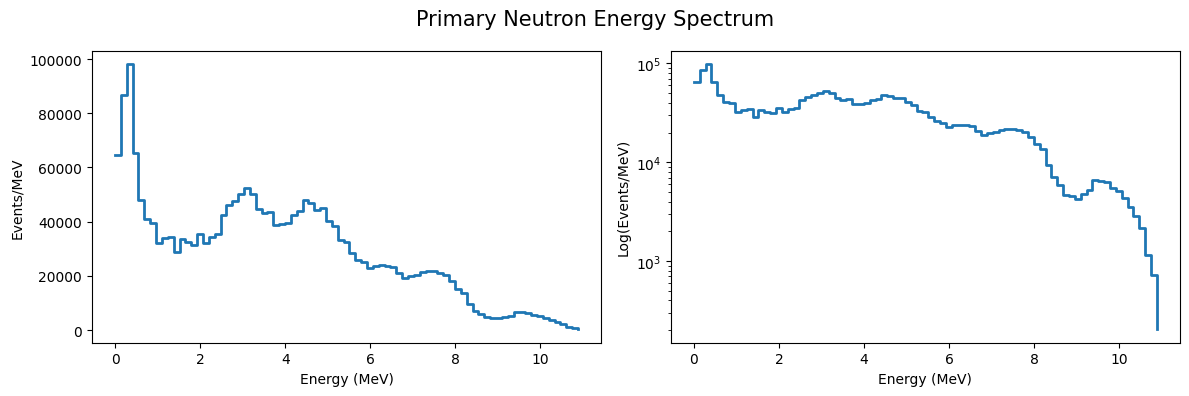

In [6]:
# plot primary neutron spectrum
pdg_ID = 2112
df_particle = gen_filtered_df(df, property='pdgID', logic='==', value=pdg_ID)
df_primary_particle = gen_filtered_df(df_particle, property='creatorProc', logic='==', value='primary')
df_primary_particle = gen_filtered_df(df_primary_particle, property='isEntry', logic='==', value=True)

primary_KE = get_df_column_as_array(df_primary_particle, col='fK1')

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

lw = 2
bins = 80

counts, bins = np.histogram(primary_KE, bins=bins)
bin_widths = np.diff(bins)
scaled_counts = counts / bin_widths
axs[0].step(bins[:-1], scaled_counts, where='post', linewidth = lw)

axs[0].set_xlabel("Energy (MeV)")
axs[0].set_ylabel("Events/MeV")

axs[1].step(bins[:-1], scaled_counts, where='post', linewidth = lw)
axs[1].set_yscale('log')
axs[1].set_xlabel("Energy (MeV)")
axs[1].set_ylabel("Log(Events/MeV)")


fig.suptitle("Primary Neutron Energy Spectrum", fontsize=15)
plt.tight_layout()

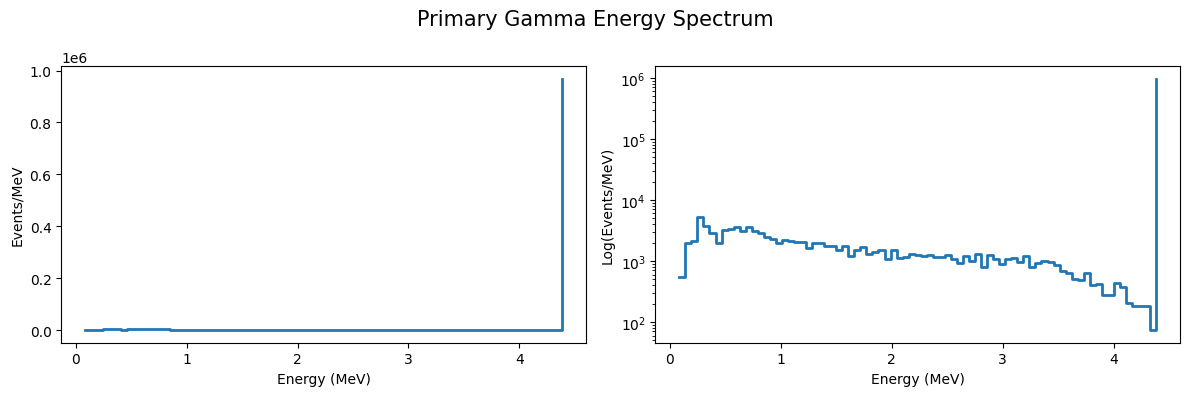

In [7]:
# plot primary gamma spectrum
pdg_ID = 22
df_particle = gen_filtered_df(df, property='pdgID', logic='==', value=pdg_ID)
df_primary_particle = gen_filtered_df(df_particle, property='creatorProc', logic='==', value='primary')
df_primary_particle = gen_filtered_df(df_primary_particle, property='isEntry', logic='==', value=True)

# NOTICE!!! The 'isEntry' captures those events entering the fiducial volume
# and therefore can still interact with the crystal surface! See the sim
# itself for more info.

primary_KE = get_df_column_as_array(df_primary_particle, col='fK1')

fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(12,4))

lw = 2
bins = 80

counts, bins = np.histogram(primary_KE, bins=bins)
bin_widths = np.diff(bins)
scaled_counts = counts / bin_widths
axs[0].step(bins[:-1], scaled_counts, where='post', linewidth = lw)

axs[0].set_xlabel("Energy (MeV)")
axs[0].set_ylabel("Events/MeV")

axs[1].step(bins[:-1], scaled_counts, where='post', linewidth = lw)
axs[1].set_yscale('log')
axs[1].set_xlabel("Energy (MeV)")
axs[1].set_ylabel("Log(Events/MeV)")


fig.suptitle("Primary Gamma Energy Spectrum", fontsize=15)
plt.tight_layout()

### Spatial Distribution of Depositions

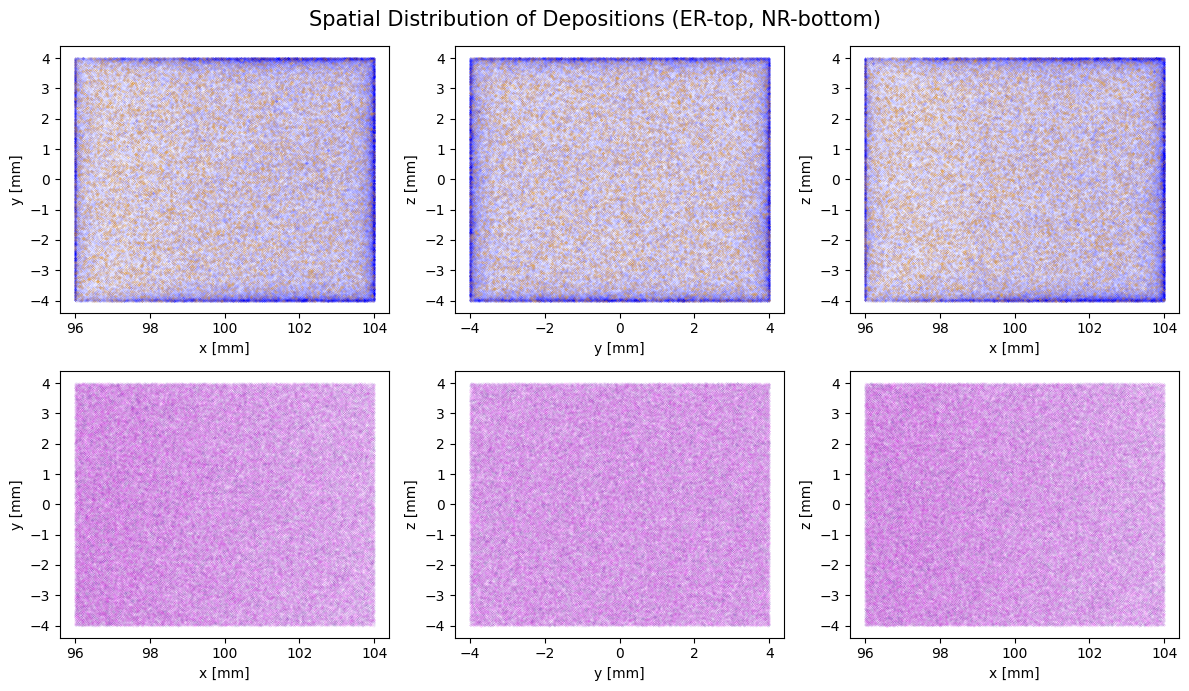

In [8]:
def get_particle_edep_df(df, pdgID):
    df_particle = gen_filtered_df(df, property='pdgID', logic='==', value=pdgID)
    df_particle = df_particle[df_particle['fEdep']>0]
    return df_particle

df_ele = get_particle_edep_df(df, 11)
ele_x = get_df_column_as_array(df_ele, col='fX1')
ele_y = get_df_column_as_array(df_ele, col='fY1')
ele_z = get_df_column_as_array(df_ele, col='fZ1')

df_gam = get_particle_edep_df(df, 22)
gam_x = get_df_column_as_array(df_gam, col='fX1')
gam_y = get_df_column_as_array(df_gam, col='fY1')
gam_z = get_df_column_as_array(df_gam, col='fZ1')

df_Li6 = get_particle_edep_df(df, 1000030060)
Li6_x = get_df_column_as_array(df_Li6, col='fX1')
Li6_y = get_df_column_as_array(df_Li6, col='fY1')
Li6_z = get_df_column_as_array(df_Li6, col='fZ1')

df_Li7 = get_particle_edep_df(df, 1000030070)
Li7_x = get_df_column_as_array(df_Li7, col='fX1')
Li7_y = get_df_column_as_array(df_Li7, col='fY1')
Li7_z = get_df_column_as_array(df_Li7, col='fZ1')

df_F19 = get_particle_edep_df(df, 1000090190)
F19_x = get_df_column_as_array(df_F19, col='fX1')
F19_y = get_df_column_as_array(df_F19, col='fY1')
F19_z = get_df_column_as_array(df_F19, col='fZ1')

fig, axs = plt.subplots(nrows=2, ncols=3, figsize=(12,7))

axs[0][0].scatter(ele_x, ele_y, s = 0.0001, color='blue')
axs[0][0].scatter(gam_x, gam_y, s = 0.005, color='orange')
axs[0][1].scatter(ele_y, ele_z, s = 0.0001, color='blue')
axs[0][1].scatter(gam_y, gam_z, s = 0.005, color='orange')
axs[0][2].scatter(ele_x, ele_z, s = 0.0001, color='blue')
axs[0][2].scatter(gam_x, gam_z, s = 0.005, color='orange')

axs[0][0].set_xlabel("x [mm]")
axs[0][0].set_ylabel("y [mm]")
axs[0][1].set_xlabel("y [mm]")
axs[0][1].set_ylabel("z [mm]")
axs[0][2].set_xlabel("x [mm]")
axs[0][2].set_ylabel("z [mm]")

axs[1][0].scatter(Li6_x, Li6_y, s = 0.0002, color='purple')
axs[1][0].scatter(Li7_x, Li7_y, s = 0.0002, color='navy')
axs[1][0].scatter(F19_x, F19_y, s = 0.0002, color='magenta')

axs[1][1].scatter(Li6_y, Li6_z, s = 0.0002, color='purple')
axs[1][1].scatter(Li7_y, Li7_z, s = 0.0002, color='navy')
axs[1][1].scatter(F19_y, F19_z, s = 0.0002, color='magenta')

axs[1][2].scatter(Li6_x, Li6_z, s = 0.0002, color='purple')
axs[1][2].scatter(Li7_x, Li7_z, s = 0.0002, color='navy')
axs[1][2].scatter(F19_x, F19_z, s = 0.0002, color='magenta')

axs[1][0].set_xlabel("x [mm]")
axs[1][0].set_ylabel("y [mm]")
axs[1][1].set_xlabel("y [mm]")
axs[1][1].set_ylabel("z [mm]")
axs[1][2].set_xlabel("x [mm]")
axs[1][2].set_ylabel("z [mm]")

fig.suptitle("Spatial Distribution of Depositions (ER-top, NR-bottom)", fontsize=15)

plt.tight_layout()

## Energy Depositions

ER contributions:
- Electrons, Positrons, Gammas

NR-elastic contributions:
- Li6, Li7, F19 (only hadElastic creatorProcs)

NR-inelastic contributions:
- Li6, Li7, F19 (only neutronInelastic creatorProcs)

Inelastic zoo contributions:
- All other ions

In [36]:
def plot_energy_dists(df, pdgID, particlename, maxE, creators=None, resolution = 100):

    lw = 2

    bins = np.linspace(0, maxE, resolution)
    bin_widths = np.diff(bins)

    fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(16,6))

    cx, _, _ = cube_centre

    df_particle = get_particle_edep_df(df, pdgID)
    if creators == None:
        unique_creators = get_df_column_as_array(df_particle, col='creatorProc', unique=True)
    else:
        unique_creators = creators

    edep_tot = np.zeros(resolution-1)

    for creator in unique_creators:
        df_creator = gen_filtered_df(df_particle, property='creatorProc', logic='==', value=creator)
        edep_creator = get_df_column_as_array(df_creator, col='fEdep')

        counts, bin_edges = np.histogram(edep_creator, bins=bins)
        bin_widths = np.diff(bin_edges)
        scaled_counts = counts / bin_widths
        edep_tot+=scaled_counts
        axs[0].step(bin_edges[:-1], scaled_counts, where='post', linewidth = lw, label=creator)

        xspats = []
        L = 10
        bin_widths = L/100
        ds = np.linspace(cx-L/2, cx+L/2, 100)
        for i in range(len(ds)-1):
            xspat_edep_df  = gen_filtered_df(df_creator, property='fX1', logic='<<', value=[ds[i], ds[i+1]])
            xspat_edep_tot = np.nansum(get_df_column_as_array(xspat_edep_df, col='fEdep'))
            xspats.append(xspat_edep_tot)

        axs[1].plot(np.divide(xspats,bin_widths), linewidth = lw, label=creator)

    axs[0].step(bin_edges[:-1], edep_tot, where='post', linewidth = 1.3*lw, label="Total", color='black')

    axs[0].set_yscale('log')
    axs[0].legend()
    axs[0].set_xlabel("Energy [MeV]")
    axs[0].set_ylabel("Counts/[MeV]")
    axs[0].set_title("Per-step Energy Spectrum per Creation Process")

    axs[1].set_yscale('log')
    axs[1].legend()
    axs[1].set_xlabel("Length [mm]")
    axs[1].set_ylabel("Energy[MeV/mm]")
    axs[1].set_title("Spatial per-Step Energy Spectrum Along Axis of Irradiation")

    fig.suptitle(f"{particlename} Energy Depositions", fontsize = 15)

    plt.tight_layout()

    return edep_tot

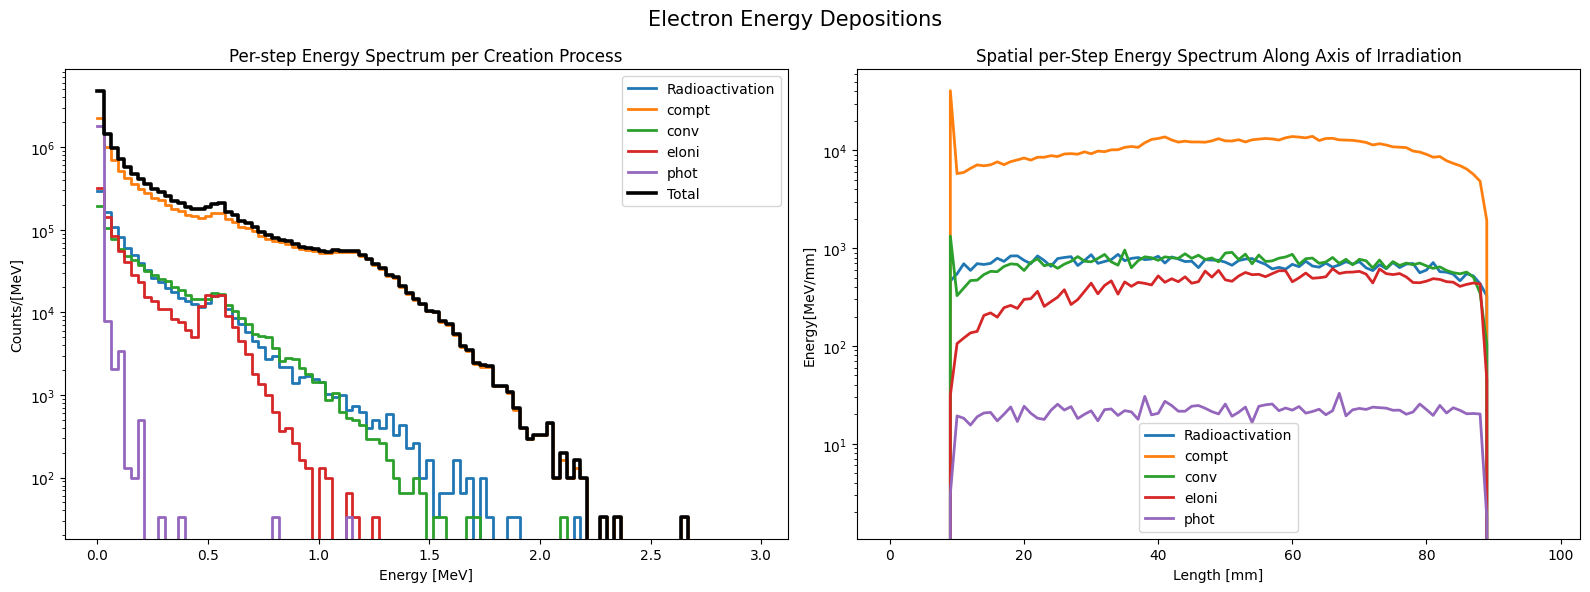

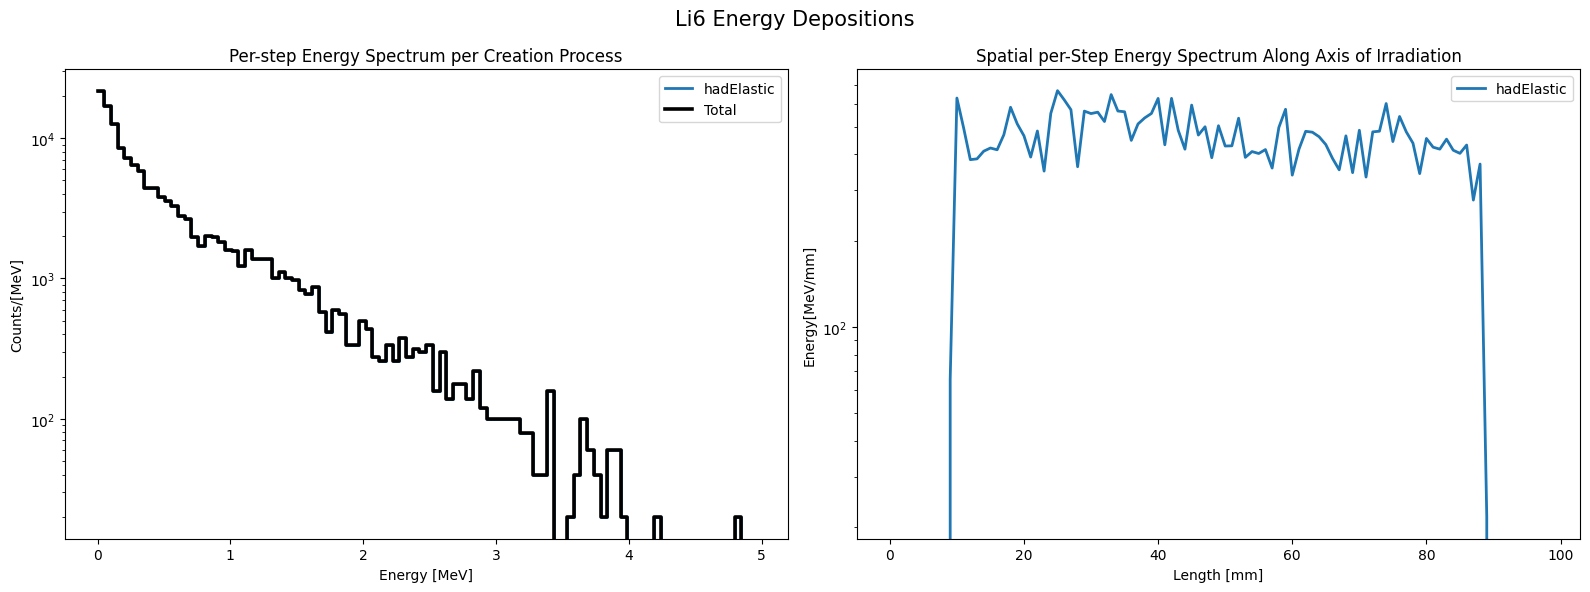

In [37]:
edep_tot_ele = plot_energy_dists(df, 11, 'Electron', maxE = 3);

plot_energy_dists(df, 1000030060, 'Li6', maxE = 5, creators=["hadElastic"]);

array([2.31858e+04, 1.76616e+04, 1.34442e+04, 9.86040e+03, 8.37540e+03,
       8.01900e+03, 7.74180e+03, 6.29640e+03, 6.17760e+03, 5.62320e+03,
       5.58360e+03, 5.02920e+03, 4.55400e+03, 3.86100e+03, 3.60360e+03,
       3.34620e+03, 3.50460e+03, 3.40560e+03, 3.04920e+03, 2.69280e+03,
       2.65320e+03, 2.47500e+03, 2.45520e+03, 2.21760e+03, 2.33640e+03,
       2.23740e+03, 1.78200e+03, 1.66320e+03, 1.62360e+03, 1.38600e+03,
       1.32660e+03, 1.22760e+03, 1.34640e+03, 1.06920e+03, 8.71200e+02,
       9.10800e+02, 7.92000e+02, 6.33600e+02, 5.34600e+02, 5.74200e+02,
       6.33600e+02, 5.74200e+02, 4.35600e+02, 4.75200e+02, 4.75200e+02,
       5.74200e+02, 4.35600e+02, 5.14800e+02, 3.56400e+02, 4.15800e+02,
       2.37600e+02, 3.96000e+02, 1.78200e+02, 2.17800e+02, 3.56400e+02,
       1.98000e+02, 2.57400e+02, 1.38600e+02, 1.38600e+02, 1.58400e+02,
       1.18800e+02, 9.90000e+01, 1.78200e+02, 9.90000e+01, 9.90000e+01,
       3.96000e+01, 5.94000e+01, 1.78200e+02, 0.00000e+00, 1.980

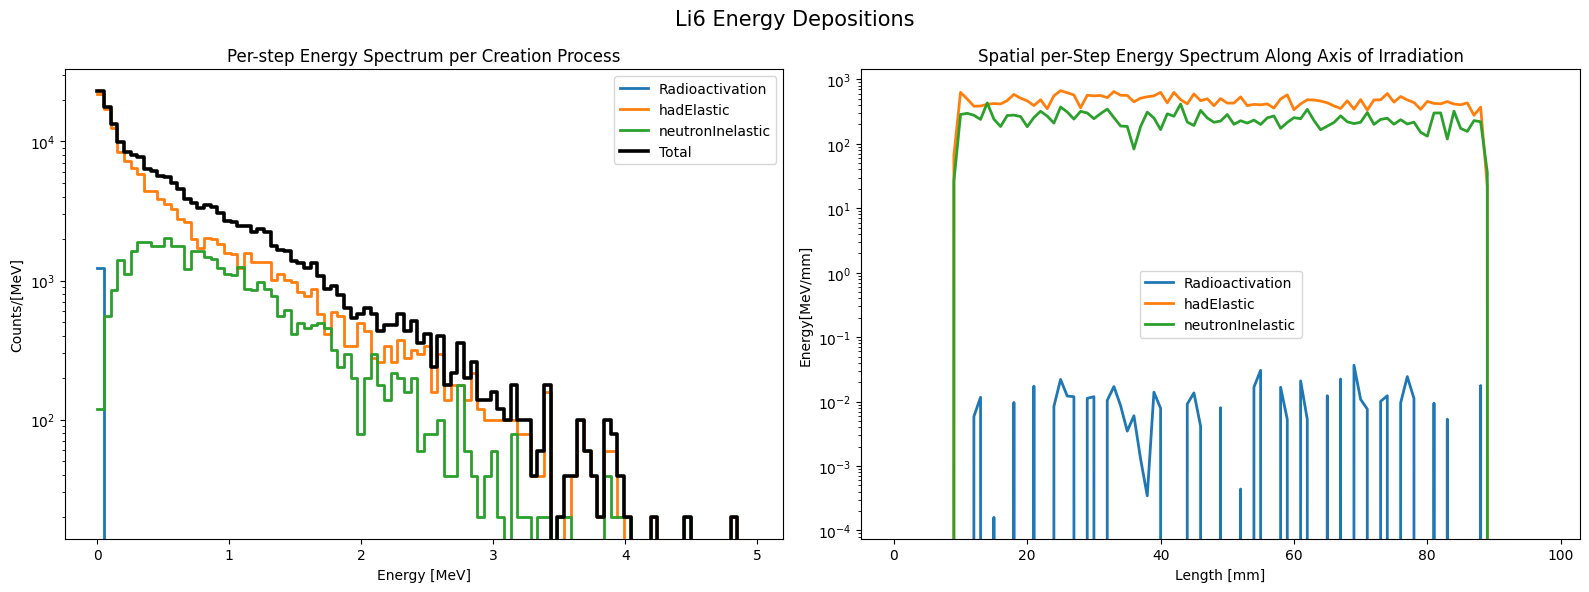

In [30]:
plot_energy_dists(df, 1000030060, 'Li6', maxE = 5)

array([3.002076e+05, 2.424708e+05, 2.089494e+05, 1.644984e+05,
       1.440846e+05, 1.290168e+05, 1.114344e+05, 1.010196e+05,
       8.941680e+04, 8.052660e+04, 7.373520e+04, 6.573600e+04,
       6.320160e+04, 5.635080e+04, 5.209380e+04, 4.773780e+04,
       4.490640e+04, 4.227300e+04, 4.150080e+04, 3.868920e+04,
       3.973860e+04, 3.633300e+04, 3.724380e+04, 3.560040e+04,
       3.393720e+04, 3.518460e+04, 3.175920e+04, 3.027420e+04,
       2.888820e+04, 2.726460e+04, 2.857140e+04, 2.425500e+04,
       2.348280e+04, 2.356200e+04, 2.086920e+04, 1.908720e+04,
       1.890900e+04, 1.609740e+04, 1.605780e+04, 1.393920e+04,
       1.300860e+04, 1.079100e+04, 1.033560e+04, 8.395200e+03,
       7.147800e+03, 6.237000e+03, 5.801400e+03, 4.930200e+03,
       4.593600e+03, 4.455000e+03, 3.861000e+03, 3.544200e+03,
       3.781800e+03, 3.009600e+03, 2.772000e+03, 2.811600e+03,
       2.514600e+03, 2.237400e+03, 1.960200e+03, 1.742400e+03,
       1.643400e+03, 1.386000e+03, 1.346400e+03, 1.2078

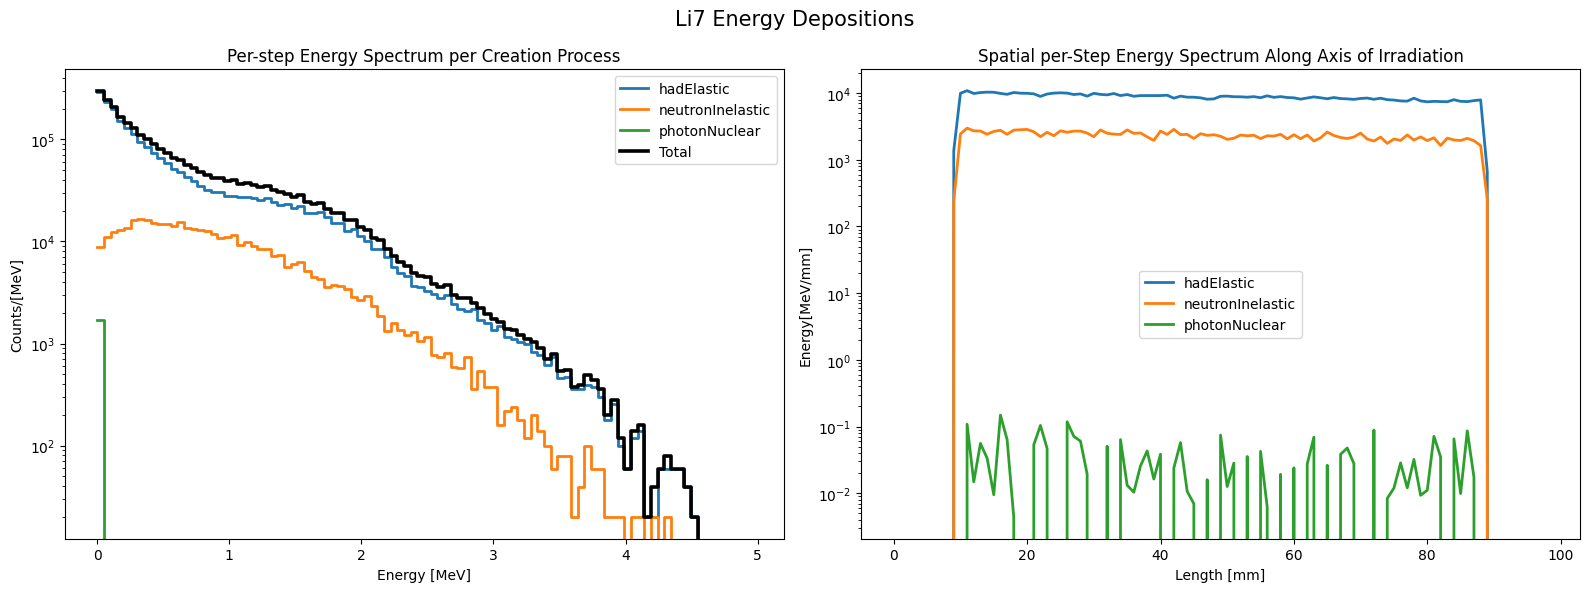

In [31]:
plot_energy_dists(df, 1000030070, 'Li7', maxE = 5)

array([1.9168875e+06, 1.1894355e+06, 8.4724200e+05, 6.2721450e+05,
       4.8222900e+05, 3.9431700e+05, 3.3268950e+05, 2.8710000e+05,
       2.4492600e+05, 2.1235500e+05, 1.8869400e+05, 1.7384400e+05,
       1.5444000e+05, 1.4879700e+05, 1.3567950e+05, 1.2261150e+05,
       1.1855250e+05, 1.1300850e+05, 1.0716750e+05, 1.0167300e+05,
       9.4743000e+04, 9.1278000e+04, 8.8258500e+04, 8.3457000e+04,
       7.9200000e+04, 7.7022000e+04, 7.2567000e+04, 6.4746000e+04,
       6.5488500e+04, 5.9548500e+04, 5.6430000e+04, 5.4252000e+04,
       4.8015000e+04, 4.7223000e+04, 4.4401500e+04, 4.1629500e+04,
       3.7224000e+04, 3.9055500e+04, 3.5541000e+04, 3.4204500e+04,
       3.0442500e+04, 2.9947500e+04, 2.6037000e+04, 2.2027500e+04,
       2.1780000e+04, 2.1879000e+04, 1.6978500e+04, 1.7028000e+04,
       1.5246000e+04, 1.5939000e+04, 1.4206500e+04, 1.2721500e+04,
       1.0543500e+04, 1.1088000e+04, 1.0197000e+04, 9.1080000e+03,
       8.4645000e+03, 7.6725000e+03, 6.5340000e+03, 5.8905000e

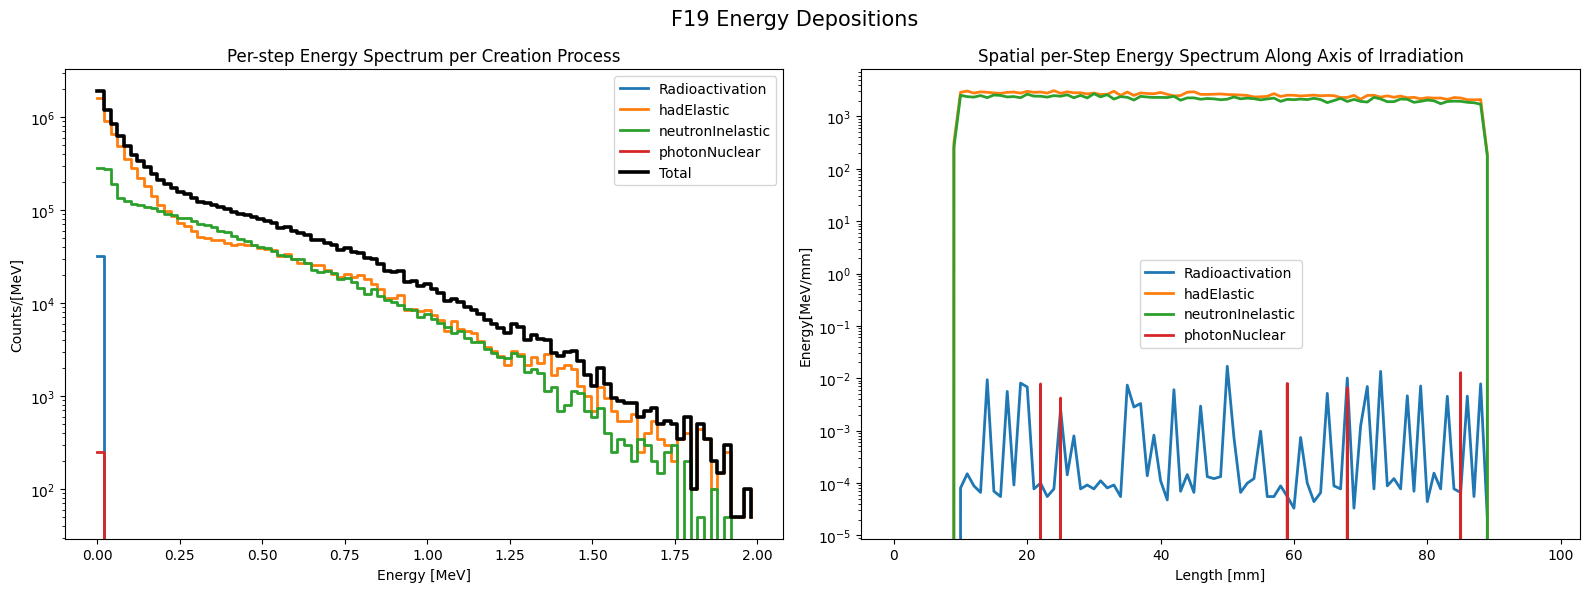

In [32]:
plot_energy_dists(df, 1000090190, 'F19', maxE=2)

In [14]:
get_edep_dict(df, pdgID=11)

{'Radioactivation': np.float32(5591.3203),
 'compt': np.float32(86984.914),
 'conv': np.float32(5708.3096),
 'eIoni': np.float32(3411.3376),
 'phot': np.float32(172.44394)}

In [15]:
get_edep_dict(df, pdgID=22)

{'Radioactivation': np.float32(1.262832e-06),
 'annihil': np.float32(5.854e-05),
 'eBrem': np.float32(0.20733297),
 'nCapture': np.float32(0.0),
 'neutronInelastic': np.float32(1.1728039),
 'phot': np.float32(0.008167259),
 'photonNuclear': np.float32(0.0),
 'primary': np.float32(0.00016397008)}

In [16]:
get_edep_dict(df, pdgID=1000030060)

{'Radioactivation': np.float32(0.05128399),
 'hadElastic': np.float32(3720.5547),
 'neutronInelastic': np.float32(1931.3549)}

In [17]:
get_edep_dict(df, pdgID=1000030070)

{'hadElastic': np.float32(70115.055),
 'neutronInelastic': np.float32(18441.535),
 'photonNuclear': np.float32(0.22523038)}

In [18]:
get_edep_dict(df, pdgID=1000090190)

{'Radioactivation': np.float32(0.014572192),
 'hadElastic': np.float32(20539.777),
 'neutronInelastic': np.float32(17446.03),
 'photonNuclear': np.float32(0.003914012)}

In [19]:
get_edep_dict(df, pdgID=1000020040)

{'neutronInelastic': np.float32(23565.941),
 'photonNuclear': np.float32(6.1401057)}

In [20]:
get_edep_dict(df, pdgID=1000010030)

{'neutronInelastic': np.float32(4591.048)}

In [21]:
get_edep_dict(df, pdgID=1000070160)

{'neutronInelastic': np.float32(5392.4297)}

In [22]:
get_edep_dict(df, pdgID=1000100200)

{'Radioactivation': np.float32(0.0010033766)}

In [23]:
tote = np.nansum(get_df_column_as_array(df, col='fEdep'))
print("Total Energy Deposited: ", tote, "MeV")

Total Energy Deposited:  275684.16 MeV
